# LSTM Train Model

## Base Initialization

### Global Parameters

In [1]:
stock_code = "GAS"

In [2]:
output_column = "close"

In [3]:
stock_code = str.lower(stock_code)

### Install libraries

In [4]:
# !pip install -r requirements.txt

### Import libraries

In [5]:
import os
import sys
import random
import numpy as np
import torch

# Set CUBLAS_WORKSPACE_CONFIG for reproducibility
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from data_preprocessor.data_preprocessor import DataPreprocessor
from dtos.model_dtos.model_config_dto import ModelConfigDto
from logger.logger import Logger, LogType
from model.lstm_model import LSTM_Model
from train_test_creator.train_test_creator import TrainTestCreator
from web_scraper.web_scraper import WebScraper
from utils.constants import *
from utils.enums import *
from utils.utils import plot_model_result

os.environ["WANDB_DISABLE_SYMLINKS"] = "true"

In [6]:
SEED = RANDOM_SEED

# Apply globally
random.seed(SEED)
np.random.seed(SEED)

In [7]:
input_size = DEFAULT_INPUT_SIZE
forecast_size = DEFAULT_FORECAST_SIZE

print(f"Input size: {input_size}")
print(f"Forecast size: {forecast_size}")

Input size: 240
Forecast size: 30


### Log Metadata

In [8]:
my_logger = Logger(
    file_name=f"{TRAINED_MODELS_LOG_FILE_BASE}/{stock_code}_lstm_train_log"
)

In [9]:
my_logger.log_info(
    f"\nTRAIN MODEL FOR STOCK: '{stock_code}' - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
)

### Load Dataframe

In [10]:
my_train_test_creator = TrainTestCreator(logger=my_logger)

In [11]:
dataframe = my_train_test_creator.load_dataframe(
    stock_code=stock_code, file_path=f"../../unified_dataframe/unified_{stock_code}.csv"
)
dataframe

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,eom_20,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10
0,2013-03-06,4.707945,42.573445,318.035806,275.767367,9.470968,428.666774,40.638065,31.087742,1423.448966,...,-0.037691,0.044115,1220.608792,964.909607,0.144175,0.147936,-0.003761,69.547974,522.980011,-7875.073746
1,2013-03-07,4.710027,42.585916,324.596774,275.848142,9.706129,428.922903,41.177742,31.329032,1423.865911,...,0.006026,0.045669,1212.631110,964.909607,0.140278,0.146404,-0.006126,45.861928,454.820285,-25492.795995
2,2013-03-08,4.712110,42.598386,331.157742,275.928918,9.941290,429.179032,41.717419,31.570323,1424.282855,...,-0.031238,0.021012,1212.631110,964.909607,0.135737,0.144271,-0.008534,-34.331403,384.941472,-14313.561330
3,2013-03-11,4.718356,42.635797,350.840645,276.171244,10.646774,429.947419,43.336452,32.294194,1425.533689,...,-0.087321,0.025443,1212.631110,964.909607,0.130898,0.141596,-0.010698,-64.185869,320.780424,-8878.216392
4,2013-03-12,4.720438,42.648267,357.401613,276.252019,10.881935,430.203548,43.876129,32.535484,1425.950634,...,-0.063236,0.059730,1217.949564,964.909607,0.126369,0.138551,-0.012182,-53.492223,267.312903,1734.980337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3022,2025-06-20,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,...,0.405180,0.028466,4676.758295,839.897191,0.030031,0.022065,0.007966,6608.683126,4585.012125,-162996.860877
3023,2025-06-23,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,...,0.454877,0.061912,4885.361903,839.897191,0.034203,0.024492,0.009711,7724.802154,5033.553558,-8951.424861
3024,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,...,0.247208,0.001295,4885.361903,780.896149,0.037826,0.027159,0.010667,6231.077840,5204.628455,-328713.260795
3025,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,...,0.120171,-0.002004,4885.361903,792.464981,0.040591,0.029846,0.010746,5858.265949,5298.005240,-155238.649006


In [12]:
dataframe.shape

(3027, 356)

## Find output range

In [13]:
dataframe.close.min(), dataframe.close.max()

(15.7183, 95.4676)

## Create train test set

In [14]:
train_test_set = my_train_test_creator.create_train_test_set(
    dataframe=dataframe,
    output_column=output_column,
    stock_code=stock_code,
    input_size=input_size,
    forecast_size=forecast_size,
)

Feature Selector Types:
['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']

Fitting feature selectors...

Fitting XGB feature selector...
Done fitting XGB feature selector...
Fitting LASSO feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.710e+02, tolerance: 1.000e+02
  model = cd_fast.enet_coordinate_descent(


Done fitting LASSO feature selector...
Fitting ELASTC NET feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.688e+02, tolerance: 1.000e+02
  model = cd_fast.enet_coordinate_descent(


Done fitting ELASTC NET feature selector...
Fitting XGB SHAP feature selector...
Done fitting XGB SHAP feature selector...

Done fitting feature selectors...
🔍 Dropped 26 highly correlated features (|r| >= 0.85):
['close_bb_lower_20', 'close_bb_middle_20', 'close_bb_upper_20', 'close_ema_12', 'close_ema_26', 'close_lwma_12', 'close_lwma_26', 'close_lwma_50', 'close_sma_50', 'close_wma_100', 'close_wma_14', 'close_wma_21', 'close_wma_50', 'close_wma_7', 'kc_lower_20', 'kc_middle_20', 'kc_upper_20', 'low', 'macd_signal_9', 'open', 'roc_9', 'starc_lower_20', 'starc_middle_20', 'starc_upper_20', 'tsi_13_7_signal_7', 'vn_index_close']
✅ Kept 14 features after pruning correlation redundancy.


### Train set

In [15]:
train_test_set.get_train_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,4.707945,42.573445,318.035806,275.767367,9.470968,428.666774,40.638065,31.087742,1423.448966,111.510968,...,0.044115,1220.608792,964.909607,0.144175,0.147936,-0.003761,69.547974,522.980011,-7875.073746,20.8390
1,4.710027,42.585916,324.596774,275.848142,9.706129,428.922903,41.177742,31.329032,1423.865911,113.366129,...,0.045669,1212.631110,964.909607,0.140278,0.146404,-0.006126,45.861928,454.820285,-25492.795995,20.7028
2,4.712110,42.598386,331.157742,275.928918,9.941290,429.179032,41.717419,31.570323,1424.282855,115.221290,...,0.021012,1212.631110,964.909607,0.135737,0.144271,-0.008534,-34.331403,384.941472,-14313.561330,20.7028
3,4.718356,42.635797,350.840645,276.171244,10.646774,429.947419,43.336452,32.294194,1425.533689,120.786774,...,0.025443,1212.631110,964.909607,0.130898,0.141596,-0.010698,-64.185869,320.780424,-8878.216392,20.7028
4,4.720438,42.648267,357.401613,276.252019,10.881935,430.203548,43.876129,32.535484,1425.950634,122.641935,...,0.059730,1217.949564,964.909607,0.126369,0.138551,-0.012182,-53.492223,267.312903,1734.980337,20.7936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2842,7.294130,94.960980,972.975000,747.835000,63.350000,178.936667,244.501667,244.650000,2220.901667,69.260000,...,-0.156469,5856.234164,731.567173,0.106208,0.103565,0.002644,319.811070,1081.816747,-73741.180021,75.8030
2843,7.299565,94.973451,970.944000,746.228000,63.082000,176.532000,242.990000,243.904000,2212.024000,68.588000,...,-0.162048,5856.234164,738.593028,0.105268,0.103905,0.001362,271.569220,966.067100,-51013.050613,76.5310
2844,7.315870,95.010861,964.851000,741.407000,62.278000,169.318000,238.455000,241.666000,2185.391000,66.572000,...,-0.166909,5898.014670,738.593028,0.105094,0.104143,0.000951,918.669599,959.296029,108399.096328,77.0770
2845,7.321304,95.023332,962.820000,739.800000,62.010000,166.913333,236.943333,240.920000,2176.513333,65.900000,...,-0.173742,5898.014670,733.360964,0.105421,0.104399,0.001022,-165.811751,798.566346,-86383.112032,76.5310


In [16]:
train_test_set.get_train_set().shape

(2847, 329)

### Val set

In [17]:
train_test_set.get_val_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,7.337609,95.060742,956.727000,734.979000,61.206000,159.699333,232.408333,238.682000,2149.880333,63.884000,...,-0.211283,5760.325069,729.000911,0.106417,0.105017,0.001399,-1956.759302,220.108481,-506945.779531,74.3
1,7.353913,95.098153,950.634000,730.158000,60.402000,152.485333,227.873333,236.444000,2123.247333,61.868000,...,-0.238459,5760.325069,712.321213,0.107043,0.105423,0.001621,-2713.950952,-199.042866,-552923.427487,72.6
2,7.359348,95.110623,948.603000,728.551000,60.134000,150.080667,226.361667,235.698000,2114.369667,61.196000,...,-0.250768,5760.325069,713.302372,0.106855,0.105709,0.001146,-2836.833407,-575.870086,-223597.694612,72.7
3,7.370217,95.135564,944.541000,725.337000,59.598000,145.271333,223.338333,234.206000,2096.614333,59.852000,...,-0.253778,5815.788997,713.302372,0.106212,0.105810,0.000402,-2596.578474,-864.542713,-9574.707327,73.4
4,7.375652,95.148034,942.510000,723.730000,59.330000,142.866667,221.826667,233.460000,2087.736667,59.180000,...,0.056589,5792.018742,713.302372,0.105219,0.105691,-0.000473,-2283.268443,-1067.217817,18057.510514,73.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,7.460444,86.573548,831.985484,576.822903,47.528065,286.841935,239.160323,230.645484,2159.756129,129.232581,...,-0.090645,5207.044074,720.714194,0.024400,0.025049,-0.000649,-668.858902,-441.397458,-27104.245200,66.4
86,7.453556,85.816129,828.761290,576.737742,47.004839,285.945161,238.564194,230.051290,2151.579677,129.483548,...,-0.064058,5207.044074,726.141259,0.024107,0.024861,-0.000753,-487.094322,-447.925581,42062.600021,66.9
87,7.446667,85.058710,825.537097,576.652581,46.481613,285.048387,237.968065,229.457097,2143.403226,129.734516,...,-0.049538,5207.044074,725.055846,0.023776,0.024644,-0.000868,-359.603070,-435.308079,23693.583662,66.8
88,7.439778,84.301290,822.312903,576.567419,45.958387,284.151613,237.371935,228.862903,2135.226774,129.985484,...,-0.092080,5214.839050,725.055846,0.023463,0.024408,-0.000944,-429.188013,-434.433784,5588.313783,66.9


In [18]:
train_test_set.get_val_set().shape

(90, 329)

### Test set

In [19]:
train_test_set.get_test_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,7.412222,81.271613,809.416129,576.226774,43.865484,280.564516,234.987419,226.486129,2102.520968,130.989355,...,-0.065384,5285.098858,723.972055,0.022850,0.023886,-0.001035,-98.335110,-387.451247,37929.301064,67.7
1,7.405333,80.514194,806.191935,576.141613,43.342258,279.667742,234.391290,225.891935,2094.344516,131.240323,...,-0.056902,5285.098858,717.555759,0.022558,0.023620,-0.001062,-189.846749,-359.222033,-8374.601017,67.1
2,7.398444,79.756774,802.967742,576.056452,42.819032,278.770968,233.795161,225.297742,2086.168065,131.491290,...,-0.022021,5285.098858,714.347611,0.022208,0.023338,-0.001130,-241.977922,-342.472874,-28591.477773,66.8
3,7.391556,78.999355,799.743548,575.971290,42.295806,277.874194,233.199032,224.703548,2077.991613,131.742258,...,-0.057829,5300.922507,714.347611,0.021822,0.023034,-0.001213,-259.585147,-330.631770,6764.456720,67.0
4,7.384667,78.241935,796.519355,575.886129,41.772581,276.977419,232.602903,224.109355,2069.815161,131.993226,...,-0.024036,5372.128929,714.347611,0.021478,0.022723,-0.001245,-73.018634,-293.829894,38494.090298,67.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,128.453333,...,0.028466,4676.758295,839.897191,0.030031,0.022065,0.007966,6608.683126,4585.012125,-162996.860877,69.5
86,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,125.590333,...,0.061912,4885.361903,839.897191,0.034203,0.024492,0.009711,7724.802154,5033.553558,-8951.424861,72.6
87,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,123.681667,...,0.001295,4885.361903,780.896149,0.037826,0.027159,0.010667,6231.077840,5204.628455,-328713.260795,67.5
88,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,122.727333,...,-0.002004,4885.361903,792.464981,0.040591,0.029846,0.010746,5858.265949,5298.005240,-155238.649006,68.5


In [20]:
train_test_set.get_test_set().shape

(90, 329)

### Normalized train set

In [21]:
train_test_set.get_norm_train_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.548284,0.000000,0.000000,0.139742,0.000000,0.542525,0.000000,0.000000,0.005678,0.173744,...,0.233857,0.000875,0.467761,0.578960,0.593050,0.304170,0.443745,0.486007,0.447933,0.064210
1,0.548388,0.000163,0.008390,0.139831,0.003334,0.542947,0.001449,0.000781,0.005779,0.179202,...,0.233961,0.000000,0.467761,0.571400,0.590011,0.279650,0.442942,0.482295,0.432703,0.062502
2,0.548493,0.000326,0.016781,0.139921,0.006668,0.543370,0.002899,0.001562,0.005880,0.184661,...,0.232312,0.000000,0.467761,0.562588,0.585776,0.254679,0.440227,0.478488,0.442367,0.062502
3,0.548808,0.000815,0.041952,0.140190,0.016671,0.544638,0.007247,0.003905,0.006182,0.201036,...,0.232609,0.000000,0.467761,0.553199,0.580468,0.232236,0.439216,0.474994,0.447066,0.062502
4,0.548913,0.000977,0.050342,0.140280,0.020005,0.545061,0.008696,0.004687,0.006283,0.206494,...,0.234901,0.000583,0.467761,0.544412,0.574424,0.216856,0.439578,0.472081,0.456240,0.063641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2842,0.678636,0.684388,0.837557,0.664261,0.763927,0.130299,0.547488,0.691336,0.198766,0.049430,...,0.220445,0.509279,0.287650,0.505294,0.504987,0.370585,0.452219,0.516446,0.390995,0.753420
2843,0.678910,0.684551,0.834959,0.662476,0.760127,0.126330,0.543428,0.688921,0.196616,0.047453,...,0.220072,0.509279,0.293073,0.503468,0.505663,0.357298,0.450586,0.510141,0.410642,0.762548
2844,0.679731,0.685040,0.827167,0.657119,0.748728,0.114422,0.531249,0.681677,0.190167,0.041521,...,0.219747,0.513861,0.293073,0.503132,0.506135,0.353033,0.472499,0.509772,0.548446,0.769395
2845,0.680005,0.685202,0.824570,0.655333,0.744928,0.110453,0.527189,0.679262,0.188018,0.039544,...,0.219290,0.513861,0.289034,0.503766,0.506643,0.353772,0.435774,0.501018,0.380067,0.762548


### Normalized val set

In [22]:
train_test_set.get_norm_val_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.680827,0.685691,0.816778,0.649977,0.733528,0.098545,0.515010,0.672017,0.181569,0.033613,...,0.216780,0.498760,0.285669,0.505698,0.507871,0.357679,0.375126,0.469510,0.016512,0.734573
1,0.681649,0.686180,0.808986,0.644620,0.722129,0.086637,0.502831,0.664772,0.175120,0.027681,...,0.214962,0.498760,0.272794,0.506914,0.508675,0.359976,0.349485,0.446680,-0.023233,0.713256
2,0.681923,0.686343,0.806389,0.642834,0.718329,0.082667,0.498772,0.662357,0.172971,0.025704,...,0.214139,0.498760,0.273551,0.506549,0.509244,0.355054,0.345324,0.426155,0.261452,0.714510
3,0.682471,0.686669,0.801194,0.639263,0.710729,0.074729,0.490652,0.657527,0.168672,0.021749,...,0.213938,0.504843,0.273551,0.505300,0.509443,0.347338,0.353459,0.410432,0.446463,0.723288
4,0.682745,0.686832,0.798597,0.637478,0.706929,0.070759,0.486593,0.655112,0.166522,0.019772,...,0.234691,0.502236,0.273551,0.503373,0.509209,0.338266,0.364069,0.399393,0.470350,0.719526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.687018,0.574815,0.657255,0.474248,0.539595,0.308417,0.533143,0.646001,0.183960,0.225886,...,0.224846,0.438080,0.279272,0.346559,0.349158,0.336445,0.418739,0.433480,0.431310,0.635513
86,0.686671,0.564920,0.653132,0.474153,0.532176,0.306936,0.531542,0.644078,0.181981,0.226624,...,0.226624,0.438080,0.283461,0.345991,0.348785,0.335361,0.424895,0.433124,0.491101,0.641782
87,0.686324,0.555025,0.649008,0.474058,0.524758,0.305456,0.529941,0.642154,0.180001,0.227363,...,0.227595,0.438080,0.282624,0.345348,0.348354,0.334174,0.429212,0.433811,0.475222,0.640529
88,0.685977,0.545130,0.644885,0.473964,0.517339,0.303976,0.528340,0.640231,0.178021,0.228101,...,0.224750,0.438935,0.282624,0.344741,0.347886,0.333379,0.426856,0.433859,0.459571,0.641782


### Normalized test set

In [23]:
train_test_set.get_norm_test_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.684588,0.505551,0.628392,0.473585,0.487665,0.298055,0.521937,0.632537,0.170102,0.231055,...,0.226535,0.446641,0.281787,0.343552,0.346849,0.332435,0.438059,0.436418,0.487528,0.651814
1,0.684241,0.495656,0.624269,0.473491,0.480246,0.296574,0.520336,0.630613,0.168122,0.231793,...,0.227103,0.446641,0.276835,0.342984,0.346322,0.332154,0.434961,0.437956,0.447501,0.644290
2,0.683893,0.485761,0.620146,0.473396,0.472827,0.295094,0.518735,0.628690,0.166142,0.232532,...,0.229435,0.446641,0.274358,0.342305,0.345762,0.331457,0.433195,0.438868,0.430024,0.640529
3,0.683546,0.475866,0.616023,0.473301,0.465409,0.293614,0.517134,0.626766,0.164163,0.233270,...,0.227041,0.448376,0.274358,0.341556,0.345160,0.330597,0.432599,0.439513,0.460588,0.643036
4,0.683199,0.465971,0.611900,0.473207,0.457990,0.292134,0.515533,0.624843,0.162183,0.234008,...,0.229300,0.456185,0.274358,0.340890,0.344543,0.330263,0.438917,0.441517,0.488016,0.654322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.706493,0.841230,0.790954,0.477067,0.898812,0.355854,0.489377,0.627489,0.331910,0.223593,...,0.232811,0.379922,0.371267,0.357485,0.343236,0.425776,0.665184,0.707256,0.313838,0.674385
86,0.708204,0.837441,0.779332,0.484927,0.879232,0.334605,0.487876,0.634979,0.324193,0.215169,...,0.235047,0.402800,0.371267,0.365580,0.348054,0.443864,0.702980,0.731687,0.447002,0.713256
87,0.709345,0.834915,0.771584,0.490167,0.866178,0.320439,0.486875,0.639973,0.319048,0.209554,...,0.230994,0.402800,0.325725,0.372610,0.353347,0.453780,0.652397,0.741005,0.170585,0.649306
88,0.709916,0.833652,0.767710,0.492787,0.859651,0.313356,0.486374,0.642470,0.316476,0.206746,...,0.230773,0.402800,0.334655,0.377975,0.358678,0.454596,0.639772,0.746091,0.320545,0.661845


### Train windows

In [24]:
print(f"Number of train windows: {len(train_test_set.get_train_windows())}")

Number of train windows: 2577


In [25]:
train_test_set.get_train_windows()[0]

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.548284,0.000000,0.000000,0.139742,0.000000,0.542525,0.000000,0.000000,0.005678,0.173744,...,0.233857,0.000875,0.467761,0.578960,0.593050,0.304170,0.443745,0.486007,0.447933,0.064210
1,0.548388,0.000163,0.008390,0.139831,0.003334,0.542947,0.001449,0.000781,0.005779,0.179202,...,0.233961,0.000000,0.467761,0.571400,0.590011,0.279650,0.442942,0.482295,0.432703,0.062502
2,0.548493,0.000326,0.016781,0.139921,0.006668,0.543370,0.002899,0.001562,0.005880,0.184661,...,0.232312,0.000000,0.467761,0.562588,0.585776,0.254679,0.440227,0.478488,0.442367,0.062502
3,0.548808,0.000815,0.041952,0.140190,0.016671,0.544638,0.007247,0.003905,0.006182,0.201036,...,0.232609,0.000000,0.467761,0.553199,0.580468,0.232236,0.439216,0.474994,0.447066,0.062502
4,0.548913,0.000977,0.050342,0.140280,0.020005,0.545061,0.008696,0.004687,0.006283,0.206494,...,0.234901,0.000583,0.467761,0.544412,0.574424,0.216856,0.439578,0.472081,0.456240,0.063641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.568037,0.065979,0.415868,0.176090,0.176580,0.400291,0.075174,0.142524,0.046565,0.565034,...,0.247518,0.108423,0.601249,0.661802,0.637466,0.514824,0.438292,0.446309,0.392620,0.358600
266,0.568171,0.066142,0.418362,0.176180,0.177237,0.394937,0.075443,0.143010,0.046665,0.558414,...,0.243296,0.108423,0.577639,0.674645,0.646664,0.535400,0.424465,0.444022,0.367487,0.343662
267,0.568305,0.066305,0.420856,0.176270,0.177894,0.389583,0.075711,0.143497,0.046766,0.551794,...,0.239785,0.108423,0.591804,0.686477,0.656444,0.547542,0.432651,0.443942,0.390498,0.352624
268,0.568439,0.066468,0.423350,0.176360,0.178551,0.384229,0.075980,0.143983,0.046867,0.545174,...,0.241418,0.108423,0.582360,0.696034,0.666222,0.547525,0.424245,0.441943,0.376076,0.346649


### Val windows

In [26]:
print(f"Number of val windows: {len(train_test_set.get_val_windows())}")

Number of val windows: 60


In [27]:
train_test_set.get_val_windows()[0]

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.581160,0.629161,0.680292,0.839068,0.716429,0.266239,0.397655,0.482054,0.290557,0.035947,...,0.262581,0.296685,0.627835,0.420294,0.417271,0.374624,0.424034,0.467410,0.390916,0.821884
1,0.581922,0.629324,0.680292,0.841935,0.716429,0.267304,0.395922,0.482054,0.290557,0.035472,...,0.252224,0.282250,0.627835,0.420910,0.418601,0.370968,0.410736,0.458954,0.355198,0.787652
2,0.582683,0.629487,0.680292,0.844803,0.716429,0.268369,0.394190,0.482054,0.290557,0.034998,...,0.249920,0.279845,0.627835,0.421406,0.419767,0.367529,0.407844,0.451042,0.413262,0.781947
3,0.583445,0.629650,0.680292,0.847670,0.716429,0.269434,0.392457,0.482054,0.290557,0.034523,...,0.245668,0.279845,0.610961,0.421690,0.420757,0.363870,0.400783,0.442637,0.379274,0.763689
4,0.584206,0.629813,0.680292,0.850538,0.716429,0.270499,0.390725,0.482054,0.290557,0.034049,...,0.240549,0.279845,0.610961,0.421281,0.421466,0.357982,0.398855,0.434990,0.394648,0.763689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.686864,0.691882,0.859393,0.619389,0.761137,0.081922,0.467882,0.690369,0.268484,-0.016145,...,0.213997,0.559632,0.218255,0.418392,0.437521,0.258661,0.389639,0.373943,0.399128,0.701971
266,0.686930,0.692045,0.863525,0.619378,0.765528,0.084343,0.468924,0.693198,0.274363,-0.016913,...,0.212012,0.554802,0.218255,0.414720,0.433535,0.259865,0.387814,0.373572,0.403360,0.695701
267,0.688705,0.696443,0.820398,0.537904,0.753066,0.177042,0.504761,0.734293,0.252043,0.004555,...,0.207715,0.533550,0.218255,0.411515,0.429690,0.262823,0.382221,0.371970,0.352800,0.668115
268,0.686996,0.692208,0.867657,0.619367,0.769919,0.086765,0.469966,0.696027,0.280242,-0.017682,...,0.209248,0.533550,0.231893,0.408528,0.426004,0.266120,0.388583,0.372058,0.473008,0.691940


### Test windows

In [28]:
print(f"Number of test windows: {len(train_test_set.get_test_windows())}")

Number of test windows: 60


In [29]:
train_test_set.get_test_windows()[0]

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.630323,0.649199,0.510957,0.810345,0.828879,0.779805,0.577997,0.667353,0.367371,0.453380,...,0.229890,0.270365,0.534684,0.389573,0.394758,0.328073,0.443003,0.469210,0.399635,0.660993
1,0.604711,0.660603,0.468127,0.633333,0.702250,0.346643,0.793212,0.708655,0.329298,0.751868,...,0.243193,0.270365,0.583257,0.388446,0.393949,0.326275,0.447282,0.468895,0.459006,0.712341
2,0.628561,0.649688,0.487145,0.775862,0.784877,0.711501,0.561328,0.653958,0.337313,0.438161,...,0.236180,0.247591,0.583257,0.387393,0.393087,0.325151,0.443566,0.467770,0.383549,0.660993
3,0.627974,0.649851,0.479207,0.764368,0.770210,0.688733,0.555771,0.649493,0.327294,0.433088,...,0.235891,0.250121,0.583257,0.386650,0.392245,0.325581,0.448305,0.467895,0.489347,0.666698
4,0.627387,0.650014,0.471270,0.752874,0.755542,0.665965,0.550215,0.645028,0.317275,0.428015,...,0.237808,0.250121,0.583257,0.385719,0.391381,0.325117,0.447413,0.467797,0.445968,0.666698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.668963,0.607563,0.487382,0.435672,0.350727,0.545151,0.505258,0.668016,0.407717,0.351819,...,0.232220,0.469349,0.265485,0.354973,0.351902,0.367074,0.453257,0.477295,0.406367,0.659337
266,0.668616,0.618516,0.496788,0.438667,0.362395,0.548223,0.508631,0.668532,0.406416,0.353145,...,0.232148,0.464940,0.265485,0.356527,0.353135,0.368935,0.441831,0.474571,0.285990,0.653068
267,0.667574,0.651374,0.525006,0.447653,0.397398,0.557440,0.518751,0.670080,0.402516,0.357123,...,0.231981,0.464940,0.265485,0.358380,0.354500,0.371705,0.426648,0.468748,0.289778,0.653068
268,0.667227,0.662327,0.534412,0.450649,0.409065,0.560513,0.522125,0.670595,0.401215,0.358449,...,0.231089,0.464940,0.262284,0.359616,0.355846,0.371283,0.424155,0.463185,0.320081,0.648052


## Setup model

In [30]:
lstm_model_config = ModelConfigDto(
    # Metadata
    entity=WANDB_ENTITY_NAME,
    project=WANDB_PROJECT_NAME,
    architecture=AchitectureType.LSTM,
    stock_code=stock_code,
    # Windowing
    window_type=WindowType.SLIDING,
    input_size=input_size,
    forecast_size=forecast_size,
    # Training
    epochs=400,
    learning_rate=0.001,
    batch_size=64,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    patience=PATIENCE,
    # Data & metrics
    scaler_type=ScalerType.MINMAX,
    metric=MetricType.MAPE,
    # Reproducibility & runtime
    seed=RANDOM_SEED,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)
lstm_model_config.format_config()

{
    "entity": "trung-lyduc18",
    "project": "master_thesis",
    "architecture": "lstm",
    "stock_code": "gas",
    "window_type": "sliding",
    "input_size": 240,
    "forecast_size": 30,
    "epochs": 400,
    "learning_rate": 0.001,
    "batch_size": 64,
    "optimizer": "adam",
    "loss_fn": "mse",
    "patience": 15,
    "scaler_type": "minmax",
    "metric": "mape",
    "device": "cuda",
    "seed": 42,
    "lr_scheduler": null
}


In [31]:
my_lstm_model = LSTM_Model(
    logger=my_logger, train_test_set=train_test_set, model_config=lstm_model_config
)

PyTorch version: 2.5.1+cu121


## Start training the model

In [32]:
model_output_dto = my_lstm_model.train()

wandb: WARNING Failed to read netrc file at C:\Users\ADMIN\_netrc, error on line 2: bad toplevel token '\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or 

Training on cuda for 400 epochs...



wandb: Currently logged in as: trung-lyduc18 (retsam-deep-learning) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1:   0%|          | 0/41 [00:00<?, ?it/s]

Epoch [1/400] - Train: 0.07994510 | Val: 0.01691835 | LR: 9.999846e-04


...

Epoch [35/400] - Train: 0.00085938 | Val: 0.00455448 | LR: 9.812276e-04


Epoch 36:   0%|          | 0/41 [00:00<?, ?it/s]

wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.
wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.


Early stopping at epoch 36 (best val loss: 0.000362)
Training completed in 58.59s
Test MAE: 6.459610
Test MAPE: 10.59%
Test RMSE: 7.509102
Test R2: -1.777345



epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
learning_rate,█████████▇▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▂▂▁▁
test_loss,▁
test_mae,▁
test_mape,▁
test_r2,▁
test_rmse,▁
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▄▂▁▁▁▂▁▂▁▁▁▂▁▁▁▂▁▁▁▁▁▂▁▁▁▂▁▂▂▁▁▁▂▃
epoch,35
learning_rate,0.00098


In [33]:
model_output_dto.mape

10.585249960422516

In [34]:
model_output_dto.y_pred_denorm

[68.6021499633789,
 68.44480895996094,
 68.39015197753906,
 69.02439880371094,
 69.3144302368164,
 68.96150207519531,
 69.52685546875,
 68.97767639160156,
 69.35261535644531,
 69.5987319946289,
 70.2477798461914,
 70.32868194580078,
 70.12777709960938,
 70.57546997070312,
 70.16351318359375,
 70.99357604980469,
 71.4181900024414,
 70.6550521850586,
 71.02914428710938,
 71.43221282958984,
 71.4932861328125,
 71.13993072509766,
 71.87057495117188,
 71.72360229492188,
 71.51750946044922,
 71.30906677246094,
 71.2310562133789,
 71.51454162597656,
 72.13882446289062,
 72.2550277709961,
 69.15931701660156,
 68.93840026855469,
 68.8763198852539,
 69.50346374511719,
 69.82938385009766,
 69.42906951904297,
 69.98523712158203,
 69.48178100585938,
 69.80143737792969,
 69.9756088256836,
 70.69378662109375,
 70.72965240478516,
 70.5510482788086,
 70.9256362915039,
 70.39507293701172,
 71.2772445678711,
 71.7207260131836,
 70.86686706542969,
 71.16565704345703,
 71.55199432373047,
 71.55889892578125

In [35]:
model_output_dto.y_true

[67.69999694824219,
 67.0999984741211,
 66.80000305175781,
 67.0,
 67.9000015258789,
 67.0999984741211,
 67.80000305175781,
 67.5999984741211,
 67.29999542236328,
 67.0,
 67.0999984741211,
 66.70000457763672,
 67.69999694824219,
 67.80000305175781,
 68.0,
 68.70000457763672,
 68.80000305175781,
 68.4000015258789,
 68.5999984741211,
 68.70000457763672,
 68.4000015258789,
 68.0,
 68.5999984741211,
 69.0999984741211,
 68.4000015258789,
 68.30000305175781,
 67.80000305175781,
 67.80000305175781,
 67.4000015258789,
 67.9000015258789,
 67.0999984741211,
 66.80000305175781,
 67.0,
 67.9000015258789,
 67.0999984741211,
 67.80000305175781,
 67.5999984741211,
 67.29999542236328,
 67.0,
 67.0999984741211,
 66.70000457763672,
 67.69999694824219,
 67.80000305175781,
 68.0,
 68.70000457763672,
 68.80000305175781,
 68.4000015258789,
 68.5999984741211,
 68.70000457763672,
 68.4000015258789,
 68.0,
 68.5999984741211,
 69.0999984741211,
 68.4000015258789,
 68.30000305175781,
 67.80000305175781,
 67.8000

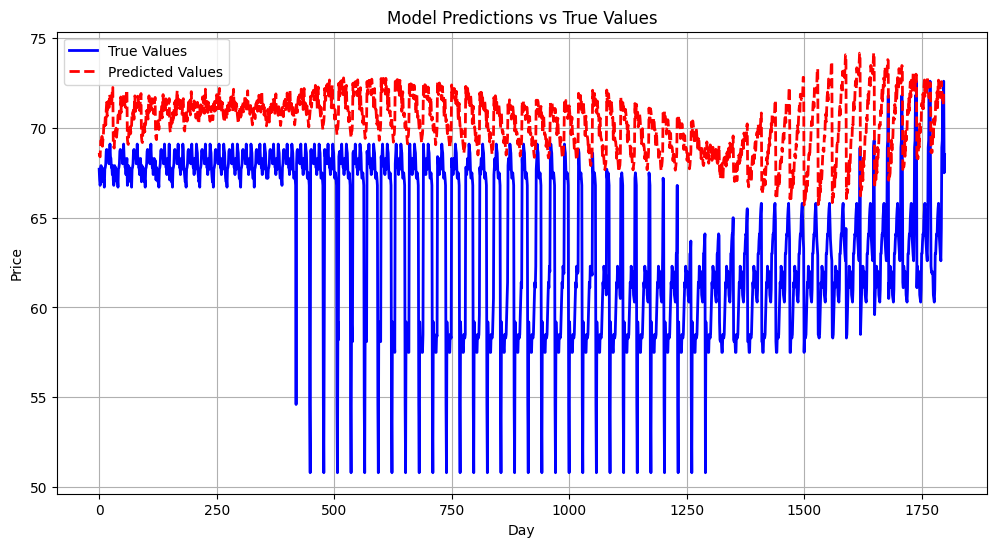

In [36]:
plot_model_result(model_output_dto=model_output_dto)